In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

df = pd.read_csv("features_cleaned.csv")

# Drop ID column
df = df.drop(columns=["ChEMBL_ID","SMILES"])

# Encode target
label_encoder = LabelEncoder()
df['Type'] = label_encoder.fit_transform(df['Type'])

# Split features and target
X = df.drop(columns=['Type'])
y = df['Type']

# Normalize continuous features only (if needed)
X_float = X.select_dtypes(include=['float64'])
scaler = StandardScaler()
X[X_float.columns] = scaler.fit_transform(X_float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = XGBClassifier(
    max_depth=12,
    learning_rate=0.008,
    n_estimators=5000,
    subsample=0.8,
    colsample_bytree=0.4,
    gamma=0,
    use_label_encoder=True,
    eval_metric='logloss',
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

print(f"Model Performance:")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

c:\Users\Manmohan\anaconda3\envs\r_env\lib\site-packages\sklearn\utils\extmath.py:1120: RuntimeWarning: overflow encountered in square
  temp **= 2
c:\Users\Manmohan\anaconda3\envs\r_env\lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\Manmohan\anaconda3\envs\r_env\lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\Manmohan\anaconda3\envs\r_env\lib\site-packages\sklearn\preprocessing\_data.py:81: RuntimeWarning: overflow encountered in square
  upper_bound = n_samples * eps * var + (n_samples * mean * eps) ** 2
c:\Users\Manmohan\anaconda3\envs\r_env\lib\site-packages\xgboost\training.py:183: UserWarning: [09:55:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.updat

Accuracy: 80.17%
Model Performance:
Classification Report:
               precision    recall  f1-score   support

    Negative       0.79      0.84      0.81      2400
    Positive       0.81      0.77      0.79      2255

    accuracy                           0.80      4655
   macro avg       0.80      0.80      0.80      4655
weighted avg       0.80      0.80      0.80      4655

Confusion Matrix:
 [[2006  394]
 [ 529 1726]]


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

df = pd.read_csv("features_cleaned.csv")

# Drop ID column
df = df.drop(columns=["ChEMBL_ID","SMILES"])

# Encode target
label_encoder = LabelEncoder()
df['Type'] = label_encoder.fit_transform(df['Type'])

# Split features and target
X = df.drop(columns=['Type'])
y = df['Type']

# Normalize continuous features only (if needed)
X_float = X.select_dtypes(include=['float64'])
scaler = StandardScaler()
X[X_float.columns] = scaler.fit_transform(X_float)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=42)

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = XGBClassifier(
    max_depth=12,
    learning_rate=0.008,
    n_estimators=5000,
    subsample=0.8,
    colsample_bytree=0.4,
    gamma=0,
    use_label_encoder=True,
    eval_metric='logloss',
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

print(f"Model Performance:")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 80.20%
Model Performance:
Classification Report:
               precision    recall  f1-score   support

    Negative       0.79      0.84      0.81      1200
    Positive       0.82      0.76      0.79      1128

    accuracy                           0.80      2328
   macro avg       0.80      0.80      0.80      2328
weighted avg       0.80      0.80      0.80      2328

Confusion Matrix:
 [[1012  188]
 [ 273  855]]


Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ FINAL VALIDATION METRICS
Accuracy  :  79.64%
F1 Score  :  78.26%
Precision :  81.08%
Recall    :  75.62%
AUC       :  87.62%
MCC       :  59.28%


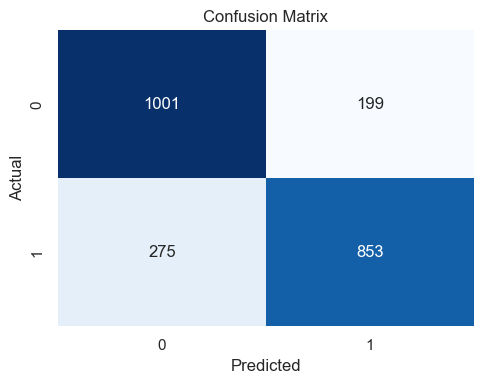

In [3]:
"""
===========================================================
UNIFIED XGBoost CLASSIFICATION PIPELINE
-----------------------------------------------------------
• Handles any tabular binary-classification dataset
• Optional label mapping OR automatic LabelEncoder
• Automated scaling, adaptive feature-selection, CV tuning
• Threshold optimisation on ROC for best FPR/TPR trade-off
• Clear metrics & confusion-matrix heat-map
===========================================================
Author: Manmohan Manchem (2025-06-26)
Python ≥3.9  |  xgboost ≥2.0
===========================================================
"""
# ---------- USER CONFIG ----------------------------------------------------
DATASET_PATH     = "features_cleaned.csv"   # <-- change here
TARGET_COL       = "Type"                            # <-- or "Type"
ID_COLS_TO_DROP  = ["ChEMBL_ID", "SMILES"]      # any ID/text cols
LABEL_MAP        = {"N": 0, "P": 1}           # or None → auto-encode
USE_GPU           = True                               # gpu_hist if available
DO_HYPER_SEARCH   = True                               # False → fixed params
MAX_BEST_FEATURES = 1000                               # k for SelectKBest
DROP_CONSTANTS    = True                               # remove 0-variance cols
RANDOM_SEED       = 42

# ---------------------------------------------------------------------------

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt, warnings, os
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute          import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# ------------------------- 1. LOAD & CLEAN ---------------------------------
df = pd.read_csv(DATASET_PATH).replace([np.inf, -np.inf], np.nan).dropna(subset=[TARGET_COL])

# drop ID/text columns
df = df.drop(columns=[c for c in ID_COLS_TO_DROP if c in df.columns], errors="ignore")

# separate target
y_raw = df.pop(TARGET_COL)
if LABEL_MAP:
    y = y_raw.map(LABEL_MAP)
else:
    le = LabelEncoder(); y = le.fit_transform(y_raw)

assert len(np.unique(y)) == 2, "`TARGET_COL` should be binary."

X = df  # remaining feature set

# ------------------------- 2. OPTIONAL CONST DROP --------------------------
if DROP_CONSTANTS:
    X = X.loc[:, X.nunique(dropna=False) > 1]

# ------------------------- 3. SCALE  → IMPUTE ------------------------------
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

imputer  = SimpleImputer(strategy="mean")
X_scaled = imputer.fit_transform(X_scaled)

# ------------------------- 4. FEATURE SELECTION ----------------------------
k_best    = min(MAX_BEST_FEATURES, X_scaled.shape[1])
selector  = SelectKBest(score_func=f_classif, k=k_best)
X_selected = selector.fit_transform(X_scaled, y)

# ------------------------- 5. TRAIN / VAL SPLIT ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_selected, y, test_size=0.1, stratify=y, random_state=RANDOM_SEED
)

# ------------------------- 6. CLASS WEIGHT ---------------------------------
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ------------------------- 7. MODEL & SEARCH -------------------------------
base_params = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="gpu_hist" if USE_GPU else "hist",
    n_jobs=-1,
    use_label_encoder=False,
)

if DO_HYPER_SEARCH:
    param_dist = {
        "n_estimators": [300, 600, 1000],
        "learning_rate": [0.008, 0.02, 0.025],
        "max_depth": [5, 7, 9, 12],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.4, 0.6, 1.0],
        "gamma": [0, 1, 5],
        "scale_pos_weight": [1, pos_weight],
    }
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    search = RandomizedSearchCV(
        XGBClassifier(**base_params),
        param_distributions=param_dist,
        n_iter=50,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_SEED,
        verbose=1,
    )
    search.fit(X_train, y_train)
    model = search.best_estimator_
else:
    fixed_params = dict(
        n_estimators=5000,
        learning_rate=0.008,
        max_depth=12,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        scale_pos_weight=pos_weight,
    )
    model = XGBClassifier(**base_params, **fixed_params)
    model.fit(X_train, y_train)

# ------------------------- 8. PREDICTION & THRESHOLD -----------------------
probs            = model.predict_proba(X_val)[:, 1]
fpr, tpr, thresh = roc_curve(y_val, probs)
best_thresh      = thresh[np.argmax(tpr - fpr)]
y_pred           = (probs >= best_thresh).astype(int)

# ------------------------- 9. METRICS --------------------------------------
metrics = {
    "Accuracy" : accuracy_score(y_val, y_pred),
    "F1 Score" : f1_score(y_val, y_pred),
    "Precision": precision_score(y_val, y_pred),
    "Recall"   : recall_score(y_val, y_pred),
    "AUC"      : roc_auc_score(y_val, probs),
    "MCC"      : matthews_corrcoef(y_val, y_pred),
}
print("\n✅ FINAL VALIDATION METRICS")
for k, v in metrics.items():
    print(f"{k:10}: {v*100:6.2f}%")

# ------------------------ 10. CONFUSION MATRIX -----------------------------
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ------------------------ 11. (OPTIONAL) SAVE MODEL ------------------------
model.save_model("xgb_model.json")

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("data_set.csv")

# Step 2: Encode the label ('P' = 1, 'N' = 0)
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Type'])

In [4]:
# Step 3: Drop non-numeric / unused columns
non_features = ['ChEMBL_ID', 'SMILES', 'Type']
df_features = df.drop(columns=non_features)

# Step 4: Separate features and labels
X = df_features.drop(columns=['Label'])
y = df_features['Label'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

In [5]:
# Step 7: Train Random Forest Classifier
rf_model = RandomForestClassifier(
    max_depth=10,
    n_estimators=5000,
)
rf_model.fit(X_train, y_train)

KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Load the dataset
df = pd.read_csv("data_set.csv")

# Step 2: Encode the label ('P' = 1, 'N' = 0)
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Type'])

# Step 3: Drop non-numeric / unused columns
non_features = ['ChEMBL_ID', 'SMILES', 'Type']
df_features = df.drop(columns=non_features)

# Step 4: Separate features and labels
X = df_features.drop(columns=['Label'])
y = df_features['Label'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Step 7: Train Random Forest Classifier
rf_model = RandomForestClassifier(
    max_depth=10,
    n_estimators=5000,
)
rf_model.fit(X_train, y_train)

# Step 8: Predict and Evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# === Load Data ===
df = pd.read_csv('data_set.csv')
assert 'Type' in df.columns, "No 'label' column found!"

# === Feature & Label Split ===
X = df.drop(columns=['ChEMBL_ID', 'SMILES', 'Type'], errors='ignore')
y = df['Type']

# === Keep only numeric features ===
X_numeric = X.select_dtypes(include=np.number)
assert not X_numeric.empty, "No numeric features!"

# === Scale Features ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# === Clustering Quality Metrics (on full feature set) ===
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, cluster_labels)
ch_score = calinski_harabasz_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)

# === Output Metrics ===
print("\n🔍 Clustering Quality Metrics (Original Features):")
print(f"✅ Silhouette Score        : {sil_score:.3f}  (higher is better, max=1)")
print(f"✅ Calinski-Harabasz Score : {ch_score:.2f}   (higher is better)")
print(f"✅ Davies-Bouldin Score    : {db_score:.3f}  (lower is better)\n")


🔍 Clustering Quality Metrics (Original Features):
✅ Silhouette Score        : 0.003  (higher is better, max=1)
✅ Calinski-Harabasz Score : 54.01   (higher is better)
✅ Davies-Bouldin Score    : 6.831  (lower is better)



In [1]:
import pandas as pd

df = pd.read_csv("data_set1.csv")
print("Shape of dataset:", df.shape)
df.dropna(inplace=True)

X = df.drop(columns=['ChEMBL_ID', 'SMILES', 'type'])
y = df['type']

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_8524\630918441.py:3: DtypeWarning: Columns (223,224,225,226,227,228,229,230,231,232,233,234,272,273,274,275,276,277,278,279,280,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,354,355,356,357,358,359,360,361,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,381,382,383,384,385,386,387,388,390,391,392,393,394,395,396,397,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,435,436,437,438,439,440,441,442,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,479,480,481,482,483,484,485,486,487,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,560,561,562,563,564,565,566,567,568,570,571,572,573,574,575,576,577,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,597,598,599,600,601,602,603,604,6

Shape of dataset: (23272, 10191)


In [6]:
import pandas as pd
import numpy as np

def clean_chemical_data_csv(file_path):
    """
    Reads a CSV file, cleans known error strings, and corrects data types.

    Args:
        file_path (str): The path to the input CSV file.

    Returns:
        pandas.DataFrame: A cleaned pandas DataFrame.
    """
    # Load the dataset from the specified CSV file
    df = pd.read_csv(file_path)

    # Define the list of specific error messages to be replaced with NaN
    # These errors were identified from the provided data sample.
    error_strings_to_replace = [
        'max() arg is an empty sequence', # 
        'min() arg is an empty sequence', # 
        'float division by zero', # 
        'module networkx has no attribute biconnected_component_subgraphs' # 
    ]

    # Replace all occurrences of the error strings with NumPy's Not a Number (NaN)
    for error_string in error_strings_to_replace:
        df.replace(error_string, np.nan, inplace=True)

    # Automatically convert columns to the best possible numeric types
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    print("Data cleaning and type conversion complete.")
    return df

# --- How to use the function ---

# 1. Specify the path to your CSV file
#    (Replace 'head_dataset.txt' with your actual file name if it's different)
input_filename = 'data_features.csv'

# 2. Call the function to get the cleaned data
cleaned_dataframe = clean_chemical_data_csv(input_filename)

# 3. (Optional) Display information about the cleaned DataFrame to verify
print("\nCleaned DataFrame Info:")
cleaned_dataframe.info()

# 4. (Optional) Display the first few rows of the cleaned data
print("\nHead of Cleaned DataFrame:")
print(cleaned_dataframe.head())

# 5. (Optional) Save the cleaned data to a new CSV file
output_filename = 'cleaned_dataset.csv'
cleaned_dataframe.to_csv(output_filename, index=False)
print(f"\nCleaned data has been saved to '{output_filename}'")

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_8524\620256006.py:15: DtypeWarning: Columns (224,225,226,227,228,229,230,231,232,233,234,235,273,274,275,276,277,278,279,280,281,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,355,356,357,358,359,360,361,362,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,382,383,384,385,386,387,388,389,391,392,393,394,395,396,397,398,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,436,437,438,439,440,441,442,443,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,480,481,482,483,484,485,486,487,488,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,561,562,563,564,565,566,567,568,569,571,572,573,574,575,576,577,578,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,598,599,600,601,602,603,604,605,

Data cleaning and type conversion complete.

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23272 entries, 0 to 23271
Columns: 10191 entries, ChEMBL_ID to AtomPair_2047
dtypes: bool(2), float64(505), int64(8767), object(917)
memory usage: 1.8+ GB

Head of Cleaned DataFrame:
       ChEMBL_ID                                             SMILES Type  \
0  CHEMBL4977690       Cc1cnc(C)c(N2CCC(n3c(=O)[nH]c4ccccc43)CC2)n1    N   
1  CHEMBL2107303  C[C@@H](OC(=O)CCc1ccccc1)[C@H]1CC[C@H]2[C@@H]3...    P   
2  CHEMBL2229306  Cc1ccc(C)c(C2=C(OC(=O)Cc3ccc(Cl)cc3Cl)C3(CCC(=...    N   
3    CHEMBL92590                   CC(=O)Nc1ccc(OC(=O)c2ccccc2O)cc1    P   
4  CHEMBL2221250  C[C@@H]1NC(=O)[C@@H](N)CNC(=O)[C@H](C2CCNC(=N)...    P   

   RD_MaxAbsEStateIndex  RD_MaxEStateIndex  RD_MinAbsEStateIndex  \
0             12.359634          12.359634              0.012798   
1             12.603924          12.603924              0.003544   
2             13.154034          13.1

Forced non-numeric values to NaN and imputed them with column means for 3605 columns.
Skipped and left as NaN (or will be dropped if uncommented): 64 columns with all missing values: ['SpAbs_Dt', 'SpMax_Dt', 'SpDiam_Dt', 'SpAD_Dt', 'SpMAD_Dt', 'LogEE_Dt', 'SM1_Dt', 'VE1_Dt', 'VE2_Dt', 'VE3_Dt', 'VR1_Dt', 'VR2_Dt', 'VR3_Dt', 'DetourIndex', 'MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXsNH3', 'MAXsSiH3', 'MAXssSiH2', 'MAXsPH2', 'MAXssPH', 'MAXsssssP', 'MAXsGeH3', 'MAXssGeH2', 'MAXsssGeH', 'MAXssssGe', 'MAXsAsH2', 'MAXssAsH', 'MAXsssssAs', 'MAXsSnH3', 'MAXssSnH2', 'MAXsssSnH', 'MAXssssSn', 'MAXsPbH3', 'MAXssPbH2', 'MAXsssPbH', 'MAXssssPb', 'MINsLi', 'MINssBe', 'MINssssBe', 'MINssBH', 'MINsNH3', 'MINsSiH3', 'MINssSiH2', 'MINsPH2', 'MINssPH', 'MINsssssP', 'MINsGeH3', 'MINssGeH2', 'MINsssGeH', 'MINssssGe', 'MINsAsH2', 'MINssAsH', 'MINsssssAs', 'MINsSnH3', 'MINssSnH2', 'MINsssSnH', 'MINssssSn', 'MINsPbH3', 'MINssPbH2', 'MINsssPbH', 'MINssssPb']
Total samples: 23,272   →   P: 11,272,   N: 1

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_18340\3619170650.py:125: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(K_range, inertia, 'bx-', color=color)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_18340\3619170650.py:131: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(K_range, sil_scores, 'ro-', color=color)


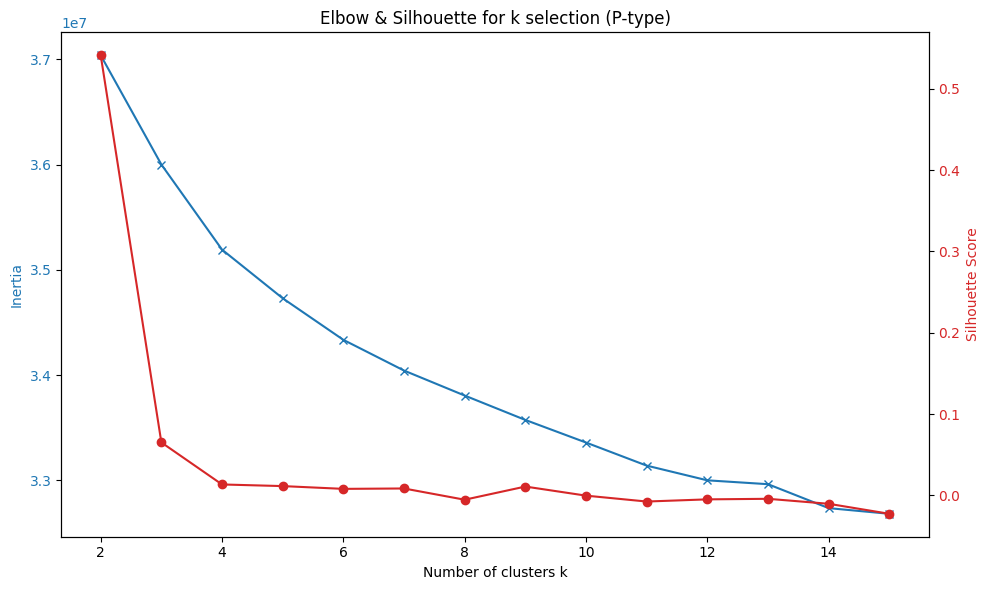

Best k for 'P-type' by silhouette score: 2

=== Metrics for subset 'P-type' (n_samples=11272) ===
Number of clusters = 2
Silhouette Score          : 0.5410   (higher ≃ better, max=1)
Calinski-Harabasz Score   : 734.51   (higher ≃ better)
Davies-Bouldin Score      : 1.2329   (lower ≃ better)



KeyboardInterrupt: 

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Load the already partially cleaned dataset
# Use low_memory=False to potentially avoid some DtypeWarnings during initial load
df = pd.read_csv("cleaned_dataset.csv", low_memory=False)

# --- IMPROVED CLEANING & IMPUTATION ---

# Define feature columns (from 'MolWt' to the second to last column)
# This assumes the last column is 'Type' and the first two are identifiers.
# Assuming the first two columns are indeed 'identifiers' and not features.
feature_cols = df.columns[2:-1].tolist() # Convert to list for easier manipulation later
label_col = df.columns[-1]

# 1. Coerce all identified feature columns to numeric, turning errors into NaN
# It's good practice to filter for numeric types if feature_cols might contain non-numeric ones.
# However, given the nature of chemical features, most should be numeric.
# This loop handles the coercion to numeric for all columns in feature_cols.
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Identify columns that are entirely NaN *after* coercion
# These are the columns SimpleImputer will skip.
cols_to_drop_or_handle_separately = []
for col in feature_cols:
    if df[col].isnull().all():
        cols_to_drop_or_handle_separately.append(col)

# Create a list of feature columns that actually contain data and will be imputed
imputable_feature_cols = [col for col in feature_cols if col not in cols_to_drop_or_handle_separately]

# Check if there are any imputable columns
if not imputable_feature_cols:
    raise ValueError("No imputable feature columns found after handling all-NaN columns. Please check your data or feature_cols definition.")

# 3. Use SimpleImputer to replace NaN values with the mean of their column *only for imputable columns*
imputer = SimpleImputer(strategy='mean')
df[imputable_feature_cols] = imputer.fit_transform(df[imputable_feature_cols])

# Optional: If you want to drop the columns that were entirely NaN, do it here.
# df = df.drop(columns=cols_to_drop_or_handle_separately)
# If you drop them, remember to update `feature_cols` accordingly.
# For now, we'll keep them as NaN but they won't be used in the clustering later.

print(f"Forced non-numeric values to NaN and imputed them with column means for {len(imputable_feature_cols)} columns.")
if cols_to_drop_or_handle_separately:
    print(f"Skipped and left as NaN (or will be dropped if uncommented): {len(cols_to_drop_or_handle_separately)} columns with all missing values: {cols_to_drop_or_handle_separately}")

# Update feature_cols to reflect only the columns that were successfully imputed
feature_cols = imputable_feature_cols
# --- END OF CLEANING FIX ---

# Separate the dataframes by type
df_p = df[df[label_col] == "P"].copy() # Use .copy() to avoid SettingWithCopyWarning
df_n = df[df[label_col] == "N"].copy() # Use .copy() to avoid SettingWithCopyWarning

# Ensure that X_p and X_n only contain the successfully imputed features
X_p = df_p[feature_cols].values
X_n = df_n[feature_cols].values

print(f"Total samples: {len(df):,}   →   P: {len(df_p):,},   N: {len(df_n):,}")

# Scale the data (this will now work without errors)
scaler_p = StandardScaler()
X_p_scaled = scaler_p.fit_transform(X_p)

scaler_n = StandardScaler()
X_n_scaled = scaler_n.fit_transform(X_n)

def find_best_k(X, max_k=15, subset_name=""):
    """Find the best k using Elbow and Silhouette methods."""
    sil_scores = []
    inertia = []
    K_range = range(2, max_k + 1)

    # Check if there's enough data for clustering
    if X.shape[0] < 2: # At least 2 samples for clustering
        print(f"Not enough samples ({X.shape[0]}) to perform clustering for {subset_name}.")
        return None
    if X.shape[0] < max_k: # Adjust max_k if less samples than max_k
        print(f"Adjusting max_k for {subset_name} as samples ({X.shape[0]}) are less than current max_k ({max_k}).")
        K_range = range(2, X.shape[0] + 1 if X.shape[0] > 1 else 2) # Ensure at least k=2 if possible
        if not K_range: # If only one sample, K_range will be empty
             print(f"Cannot form clusters for {subset_name} as samples ({X.shape[0]}) is too small for K_range.")
             return None

    for k in K_range:
        # Check if k is greater than the number of samples, which can cause issues
        if k > X.shape[0]:
            print(f"Skipping k={k} for {subset_name} as it's greater than the number of samples ({X.shape[0]}).")
            continue # Skip to the next k

        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertia.append(km.inertia_)
        
        # Silhouette score requires at least 2 samples and 2 clusters
        if k > 1 and len(np.unique(labels)) > 1: # Ensure at least 2 distinct clusters are formed
            sil_scores.append(silhouette_score(X, labels))
        else:
            sil_scores.append(-1) # Assign a low score if silhouette cannot be computed meaningfully

    if not K_range or not sil_scores: # Handle cases where K_range might be empty or no sil_scores
        print(f"Could not determine best k for '{subset_name}'.")
        return None

    # Plotting for K-means results
    # Only plot if there's meaningful data to plot
    if len(K_range) > 1 and len(inertia) == len(K_range) and len(sil_scores) == len(K_range):
        fig, ax1 = plt.subplots(figsize=(10, 6))

        color = 'tab:blue'
        ax1.set_xlabel('Number of clusters k')
        ax1.set_ylabel('Inertia', color=color)
        ax1.plot(K_range, inertia, 'bx-', color=color)
        ax1.tick_params(axis='y', labelcolor=color)

        ax2 = ax1.twinx()
        color = 'tab:red'
        ax2.set_ylabel('Silhouette Score', color=color)
        ax2.plot(K_range, sil_scores, 'ro-', color=color)
        ax2.tick_params(axis='y', labelcolor=color)

        plt.title(f'Elbow & Silhouette for k selection ({subset_name})')
        fig.tight_layout()
        plt.show()
    else:
        print(f"Not enough data points or valid K_range to generate Elbow and Silhouette plot for {subset_name}.")

    # Find best_k from valid silhouette scores
    valid_sil_scores_indices = [i for i, score in enumerate(sil_scores) if score != -1]
    if valid_sil_scores_indices:
        best_k_index = valid_sil_scores_indices[np.argmax([sil_scores[i] for i in valid_sil_scores_indices])]
        best_k = K_range[best_k_index]
        print(f"Best k for '{subset_name}' by silhouette score: {best_k}")
        return best_k
    else:
        print(f"No valid silhouette scores to determine best k for '{subset_name}'.")
        return None


def compute_metrics(X, subset_name, n_clusters):
    """Perform KMeans clustering and print evaluation metrics."""
    if n_clusters is None or X.shape[0] < n_clusters:
        print(f"\nSkipping metrics for subset '{subset_name}': Not enough samples or invalid n_clusters ({n_clusters}).")
        return
    if X.shape[0] < 2: # At least 2 samples for metrics
        print(f"\nSkipping metrics for subset '{subset_name}': Not enough samples ({X.shape[0]}).")
        return

    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    # Ensure there are at least 2 unique labels for silhouette and Davies-Bouldin scores
    if len(np.unique(labels)) < 2:
        print(f"\nSkipping metrics for subset '{subset_name}': KMeans formed less than 2 distinct clusters with n_clusters={n_clusters}.")
        return

    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)

    print(f"\n=== Metrics for subset '{subset_name}' (n_samples={X.shape[0]}) ===")
    print(f"Number of clusters = {n_clusters}")
    print(f"Silhouette Score          : {sil:.4f}   (higher ≃ better, max=1)")
    print(f"Calinski-Harabasz Score   : {ch:.2f}   (higher ≃ better)")
    print(f"Davies-Bouldin Score      : {db:.4f}   (lower ≃ better)")
    print("")

# Find the best k and compute metrics for P-type
best_k_p = find_best_k(X_p_scaled, subset_name="P-type")
if best_k_p is not None:
    compute_metrics(X_p_scaled, "P-type", best_k_p)

# Find the best k and compute metrics for N-type
best_k_n = find_best_k(X_n_scaled, subset_name="N-type") # Changed N‐type to N-type for consistency
if best_k_n is not None:
    compute_metrics(X_n_scaled, "N-type", best_k_n)

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_3920\3701944862.py:50: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(K_range, inertia, 'bx-', color=color)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_3920\3701944862.py:56: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(K_range, sil_scores, 'ro-', color=color)


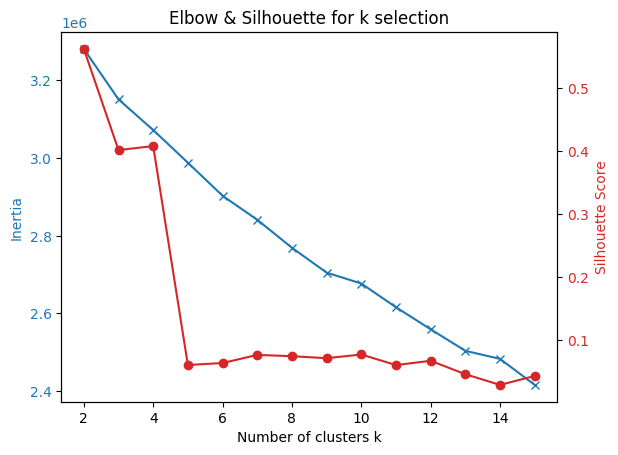

Best k by silhouette score: 2

=== Metrics for subset 'P-type' (n_samples=11272) ===
Number of clusters = 2
Silhouette Score        : 0.5617    (higher ≃ better, max=1)
Calinski-Harabasz Score : 857.00    (higher ≃ better)
Davies-Bouldin Score    : 1.3506    (lower ≃ better)



In [19]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=50).fit_transform(X_p_scaled)
find_best_k(X_pca)
compute_metrics(X_pca, "P-type", 2)

In [20]:
from sklearn.cluster import AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters=2)
labels = clustering.fit_predict(X_pca)

from sklearn.metrics import silhouette_score
print("Silhouette Score:", silhouette_score(X_pca, labels))

Silhouette Score: 0.5413803759321054


💡 Columns with only NaNs (after inf replacement): 0
📊 Max after clipping: 1000000.0
📊 Min after clipping: -178.74892853445044
🧪 Dataset shape after cleaning: (23272, 4307)


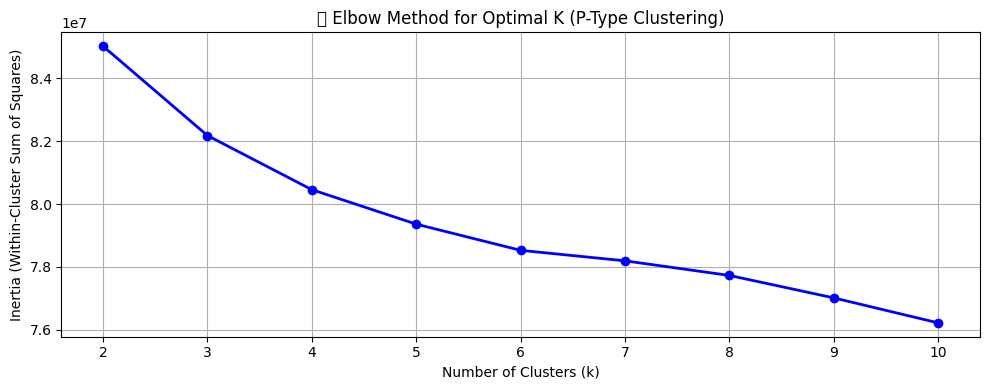

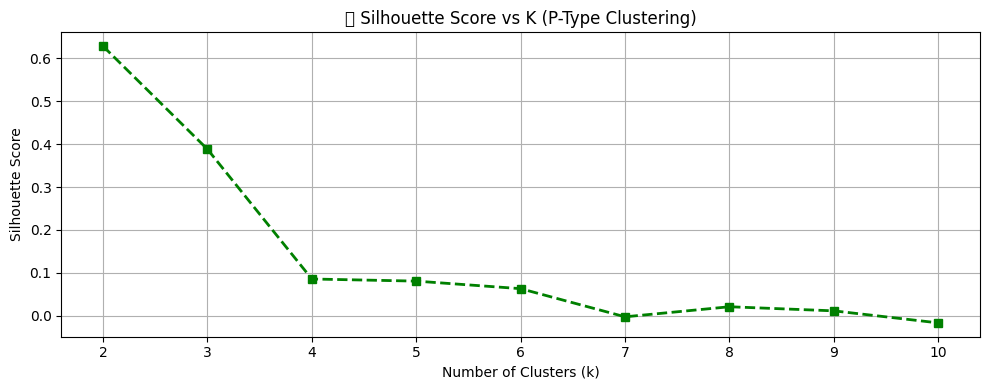

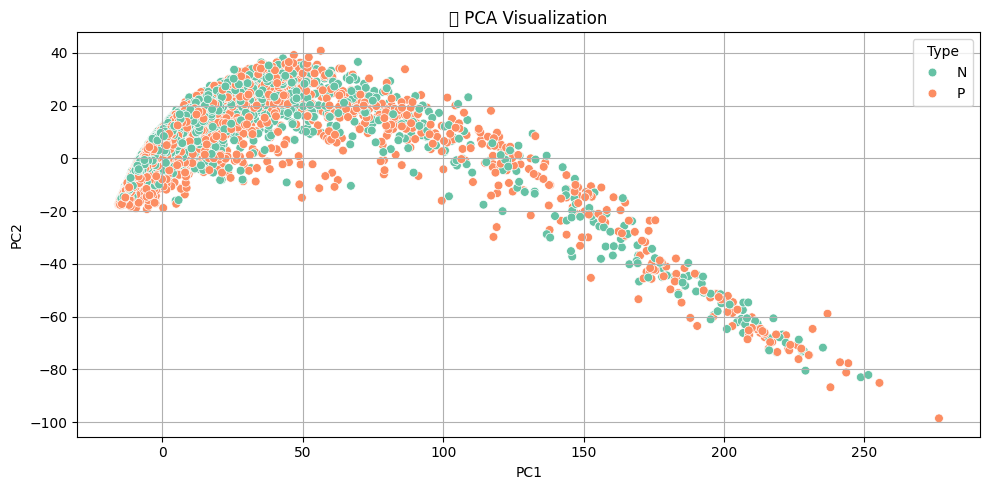

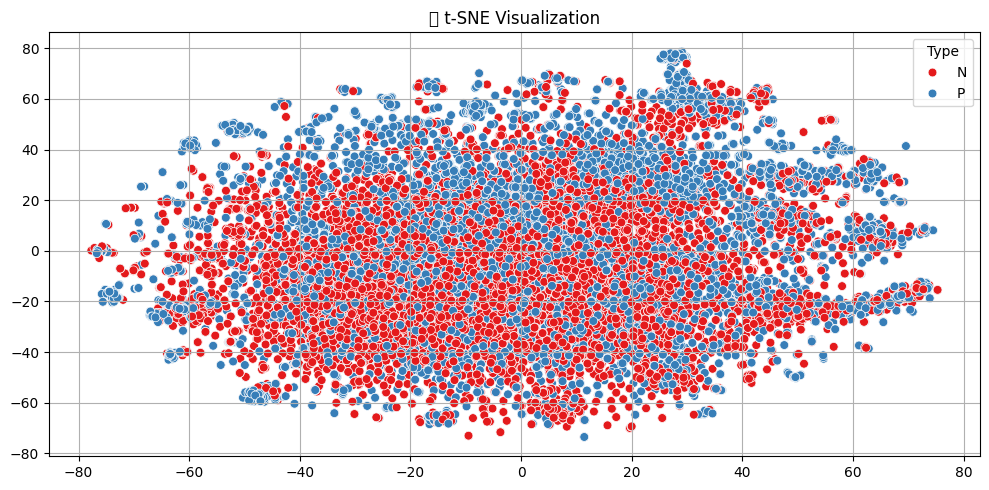

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# === Load Dataset === #
df = pd.read_csv("new_features_cleaned.csv")

# === Keep Only Numeric Features === #
numeric_cols = df.select_dtypes(include=[np.number]).columns
X = df[numeric_cols]

# === Optional: Keep label for coloring === #
label_col = "Type"
labels = df[label_col] if label_col in df.columns else None

# === Step 1: Replace inf/-inf with NaN === #
X = X.replace([np.inf, -np.inf], np.nan)

# === Step 2: Drop Columns With All NaNs === #
nan_stats = X.isna().sum()
all_nan_cols = nan_stats[nan_stats == len(X)].index.tolist()
print(f"💡 Columns with only NaNs (after inf replacement): {len(all_nan_cols)}")
if all_nan_cols:
    print("🧹 Dropping columns:", all_nan_cols)
X = X.drop(columns=all_nan_cols)

# === Step 3: Clip Extreme Outliers === #
MAX_ABS_THRESHOLD = 1e6
X = X.clip(lower=-MAX_ABS_THRESHOLD, upper=MAX_ABS_THRESHOLD)

print(f"📊 Max after clipping: {np.nanmax(X.values)}")
print(f"📊 Min after clipping: {np.nanmin(X.values)}")
print(f"🧪 Dataset shape after cleaning: {X.shape}")

# === Step 4: Impute Missing Values === #
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# === Step 5: Scale the Data === #
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# === Step 6: Final Sanity Check === #
assert not np.isnan(X_scaled).any(), "😱 Still contains NaNs after cleaning!"

# === KMeans Clustering Analysis (Elbow & Silhouette) === #
inertia = []
sil_scores = []
K_range = range(2, 11)  # You can increase this range if needed

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, cluster_labels))

# === Elbow Plot === #
plt.figure(figsize=(10, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, marker='o')
plt.title("📉 Elbow Method for Optimal K (P-Type Clustering)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Silhouette Score Plot === #
plt.figure(figsize=(10, 4))
plt.plot(K_range, sil_scores, 'gs--', linewidth=2, marker='s')
plt.title("📈 Silhouette Score vs K (P-Type Clustering)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# === PCA === #
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="Set2", s=40)
plt.title("🔍 PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

# === t-SNE === #
X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, init='pca', random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette="Set1", s=40)
plt.title("🔍 t-SNE Visualization")
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# === Load dataset ===
df = pd.read_csv("new_features_cleaned.csv")  # Replace with your actual path

# === Setup column groups ===
label_col = "Type"
cols_to_skip = ["ChEMBL_ID", "SMILES"]
feature_cols = [col for col in df.columns if col not in [label_col] + cols_to_skip]

# === Impute missing values ===
imputer = SimpleImputer(strategy="mean")
df[feature_cols] = imputer.fit_transform(df[feature_cols])
print(f"✅ Imputed {len(feature_cols)} columns with mean.")

# === Replace infs ===
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
na_cols = df[feature_cols].isna().sum()
nan_only_cols = na_cols[na_cols == len(df)].index.tolist()
print(f"💡 Columns with only NaNs (after inf replacement): {len(nan_only_cols)}")

# Drop columns with all NaNs and any remaining rows with NaNs
df.drop(columns=nan_only_cols, inplace=True)
df.dropna(subset=feature_cols, inplace=True)

# === Optional: Clip large outliers ===
df[feature_cols] = df[feature_cols].clip(lower=-1e10, upper=1e10)

# === Label sanitization ===
df[label_col] = df[label_col].astype(str).str.upper().str.strip()
print("✅ Unique labels:", df[label_col].unique())

# === Dataset stats ===
print(f"🧪 Dataset shape after cleaning: {df.shape}")
print(f"📊 Max value: {df[feature_cols].max().max()}")
print(f"📊 Min value: {df[feature_cols].min().min()}")

# === Subset by label ===
df_p = df[df[label_col] == "P"]
df_n = df[df[label_col] == "N"]
if df_p.empty or df_n.empty:
    raise ValueError("❌ One of the classes is missing after cleaning!")

print(f"✅ Sample counts – Total: {len(df)}, P: {len(df_p)}, N: {len(df_n)}")

# === Shared scaler ===
scaler = StandardScaler()
X_p_scaled = scaler.fit_transform(df_p[feature_cols])
X_n_scaled = scaler.fit_transform(df_n[feature_cols])

# === Clustering utilities ===
def evaluate_clustering(X, subset_name):
    silhouette_scores = []
    best_k = 2
    for k in range(2, 11):
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        sil = silhouette_score(X, labels)
        silhouette_scores.append(sil)
    best_k = np.argmax(silhouette_scores) + 2
    print(f"🔎 [{subset_name}] Best k = {best_k} by silhouette")

    # Final clustering and metrics
    final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = final_model.fit_predict(X)
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    print(f"\n📌 [{subset_name}] Metrics for k={best_k}:")
    print(f"  Silhouette Score        : {sil:.4f}")
    print(f"  Calinski-Harabasz Score : {ch:.4f}")
    print(f"  Davies-Bouldin Score    : {db:.4f}")
    return labels

# === Run clustering ===
labels_p = evaluate_clustering(X_p_scaled, "P-type")
labels_n = evaluate_clustering(X_n_scaled, "N-type")


✅ Imputed 4307 columns with mean.
💡 Columns with only NaNs (after inf replacement): 0


KeyboardInterrupt: 